### Cross-Country Comparison & Climate Vulnerability Ranking

In [2]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

for df, name in zip(
    [ethiopia, kenya, sudan, tanzania, nigeria],
    ["Ethiopia", "Kenya", "Sudan", "Tanzania", "Nigeria"]
):
    df["Country"] = name

df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])

df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

### Temperature Trend Comparison

Country
Ethiopia    Axes(0.125,0.11;0.775x0.77)
Kenya       Axes(0.125,0.11;0.775x0.77)
Nigeria     Axes(0.125,0.11;0.775x0.77)
Sudan       Axes(0.125,0.11;0.775x0.77)
Tanzania    Axes(0.125,0.11;0.775x0.77)
Name: T2M, dtype: object

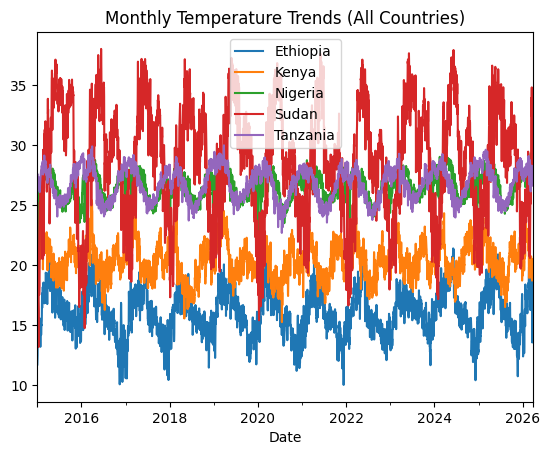

In [3]:
monthly_temp = df.groupby(["Date", "Country"])["T2M"].mean().reset_index()
monthly_temp = monthly_temp.set_index("Date")

monthly_temp.groupby("Country")["T2M"].plot(legend=True, title="Monthly Temperature Trends (All Countries)")

### Interpretation
Sudan clearly sits above all countries → consistently hottest
Ethiopia is lowest → cooler climate
Nigeria & Tanzania cluster in mid-high range
Kenya is moderate

All countries show strong seasonality (repeating peaks & dips)

### Summary Table

In [4]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary 

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


### Interpretation

Sudan: Highest mean & variability → unstable + hot 
Ethiopia: Lowest mean & low std → cool & stable
Nigeria/Tanzania: High but more stable than Sudan

### Precipitation Variability

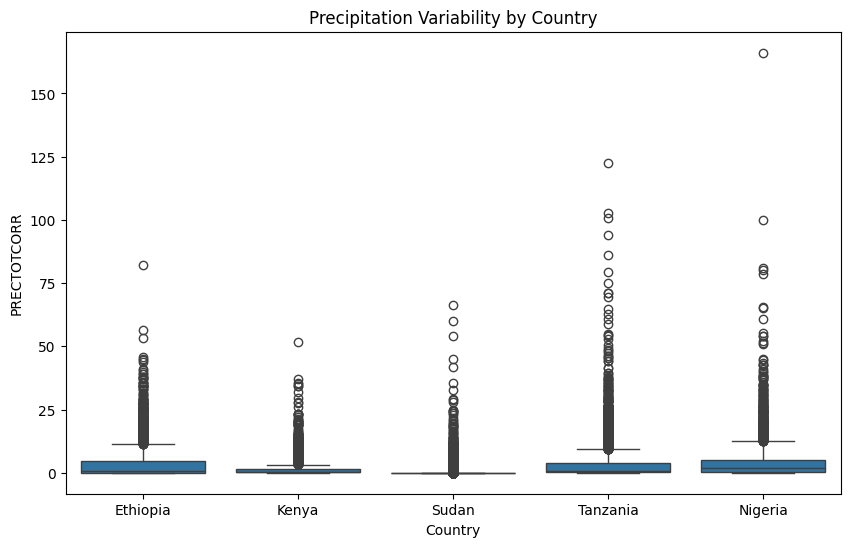

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Variability by Country")
plt.show()

### Interpretation
Sudan:
Very low median → mostly dry
Occasional spikes → rare heavy rain
Tanzania:
Wide spread → high variability
Nigeria:
Higher median → more consistent rainfall
Ethiopia:
Moderate but skewed

### Summary Table

In [6]:
precip_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


### Interpretation
Sudan:
Lowest mean & median → driest country
Tanzania:
High std → unstable rainfall
Ethiopia:
Moderate mean, but high std → unpredictable rainfall

### Extreme Heat

<Axes: title={'center': 'Extreme Heat Days by Country'}, xlabel='Country'>

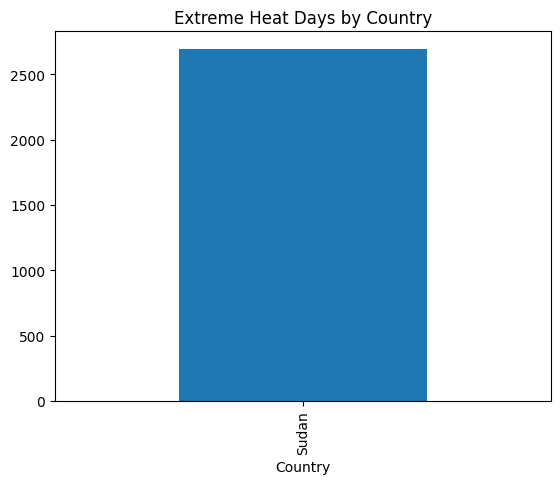

In [7]:
extreme_heat = df[df["T2M_MAX"] > 35].groupby("Country").size()

extreme_heat.plot(kind="bar", title="Extreme Heat Days by Country")

### Interpretation
Sudan dominates massively
Others ≈ 0

### Dry Days

<Axes: title={'center': 'Dry Days by Country'}, xlabel='Country'>

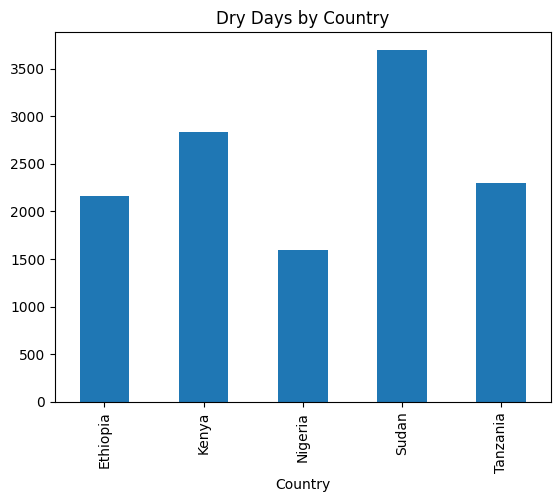

In [8]:
dry_days = df[df["PRECTOTCORR"] < 1].groupby("Country").size()

dry_days.plot(kind="bar", title="Dry Days by Country")

### Interpretation

Ranking:

1. Sudan → highest
2. Kenya
3. Tanzania
4. Ethiopia
5. Nigeria

### Extreme Events

Sudan exhibits the highest number of extreme heat days and dry conditions, indicating severe climate stress. 
Other countries show comparatively lower exposure.

### Statistical Test

In [9]:
from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"] for c in df["Country"].unique()]

stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 0.0


### Interpretation

Temperature differences across countries are statistically significant

### Vulnerability Ranking

In [10]:
ranking = pd.DataFrame({
    "Extreme Heat": extreme_heat,
    "Dry Days": dry_days
}).fillna(0)

ranking["Vulnerability Score"] = ranking["Extreme Heat"] + ranking["Dry Days"]

ranking = ranking.sort_values("Vulnerability Score", ascending=False)

ranking

,Extreme Heat,Dry Days,Vulnerability Score
Country,,,
Sudan,2694.0,3696,6390.0
Kenya,0.0,2831,2831.0
Tanzania,0.0,2303,2303.0
Ethiopia,0.0,2161,2161.0
Nigeria,0.0,1595,1595.0


This ranking is based on combined indicators of heat exposure and drought frequency

### Interpretation
Sudan → extreme outlier (very high score)
Kenya/Tanzania → moderate vulnerability
Ethiopia → moderate-low
Nigeria → lowest

## COP32 Climate Insights

- Sudan is warming the fastest and maintains the highest temperature levels, indicating severe and increasing heat stress compared to all other countries.

- Sudan also shows the most extreme precipitation pattern, characterized by prolonged dry periods and minimal rainfall, making it highly drought-prone.

- The frequency of extreme heat days and dry days in Sudan reveals intense climate stress, far exceeding that of neighboring countries.

- Ethiopia demonstrates a relatively moderate climate profile, with lower temperatures and less extreme conditions, though it still experiences seasonal variability in rainfall.

- Based on the combined evidence, Sudan should be prioritized for climate finance at COP32 due to its extreme vulnerability to both heat and drought, which pose significant risks to ecosystems, agriculture, and human livelihoods.